In [1]:
import os
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt

In [3]:
#############################################################################
# DATASET PATH
DATASET_PATH = r"D:\ANN and DL\audio"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Number of class folders:", len(os.listdir(DATASET_PATH)))

Dataset exists: True
Number of class folders: 1


In [4]:
#############################################################################
# LOAD AUDIO DATASET
train_set, test_set = tf.keras.utils.audio_dataset_from_directory(
    directory=DATASET_PATH,
    batch_size=16,
    validation_split=0.2,
    output_sequence_length=16000,
    seed=0,
    subset="both"
)

Found 3000 files belonging to 1 classes.
Using 2400 files for training.
Using 600 files for validation.


In [6]:
#############################################################################
# LABELS
label_names = np.array(train_set.class_names)
num_classes = len(label_names)
print("Classes:", label_names)

Classes: ['free-spoken-digit-dataset-master']


In [7]:
#############################################################################
# REMOVE CHANNEL DIMENSION
def squeeze(audio, label):
    audio = tf.squeeze(audio, axis=-1)
    return audio, label

train_set = train_set.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)
test_set  = test_set.map(squeeze, num_parallel_calls=tf.data.AUTOTUNE)

In [8]:
#############################################################################
# MEL-SPECTROGRAM (TENSORFLOW)
def mel_spectrogram(audio, label):

    stft = tf.signal.stft(
        audio,
        frame_length=256,
        frame_step=128
    )

    spectrogram = tf.abs(stft)

    mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=40,
        num_spectrogram_bins=spectrogram.shape[-1],
        sample_rate=16000,
        lower_edge_hertz=80.0,
        upper_edge_hertz=7600.0
    )

    mel_spec = tf.tensordot(spectrogram, mel_filterbank, 1)
    mel_spec = tf.math.log(mel_spec + 1e-6)

    # Add channel dimension for CNN
    mel_spec = mel_spec[..., tf.newaxis]

    return mel_spec, label

train_set = train_set.map(mel_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)
test_set  = test_set.map(mel_spectrogram, num_parallel_calls=tf.data.AUTOTUNE)

In [9]:
#############################################################################
# PERFORMANCE
train_set = train_set.prefetch(tf.data.AUTOTUNE)
test_set  = test_set.prefetch(tf.data.AUTOTUNE)

#############################################################################
# SANITY CHECK
for x, y in train_set.take(1):
    print("Input shape:", x.shape)
    print("Labels shape:", y.shape)

Input shape: (16, 124, 40, 1)
Labels shape: (16,)


In [10]:
#############################################################################
# CNN MODEL
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=x.shape[1:]),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()




Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 122, 38, 32)       320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 61, 19, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 59, 17, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 29, 8, 64)         0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 27, 6, 128)        73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 13, 3, 128)      

In [11]:
#############################################################################
# TRAIN MODEL
history = model.fit(
    train_set,
    epochs=15,
    validation_data=test_set
)

Epoch 1/15


150/150 [==============================] - 14s 76ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 2/15
150/150 [==============================] - 11s 70ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 3/15
150/150 [==============================] - 11s 70ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 4/15
150/150 [==============================] - 11s 71ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 5/15
150/150 [==============================] - 11s 72ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 6/15
150/150 [==============================] - 11s 75ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00 - val_loss: 0.0000e+00 - val_accuracy: 0.0000e+00
Epoch 7/15
150/150 [==================

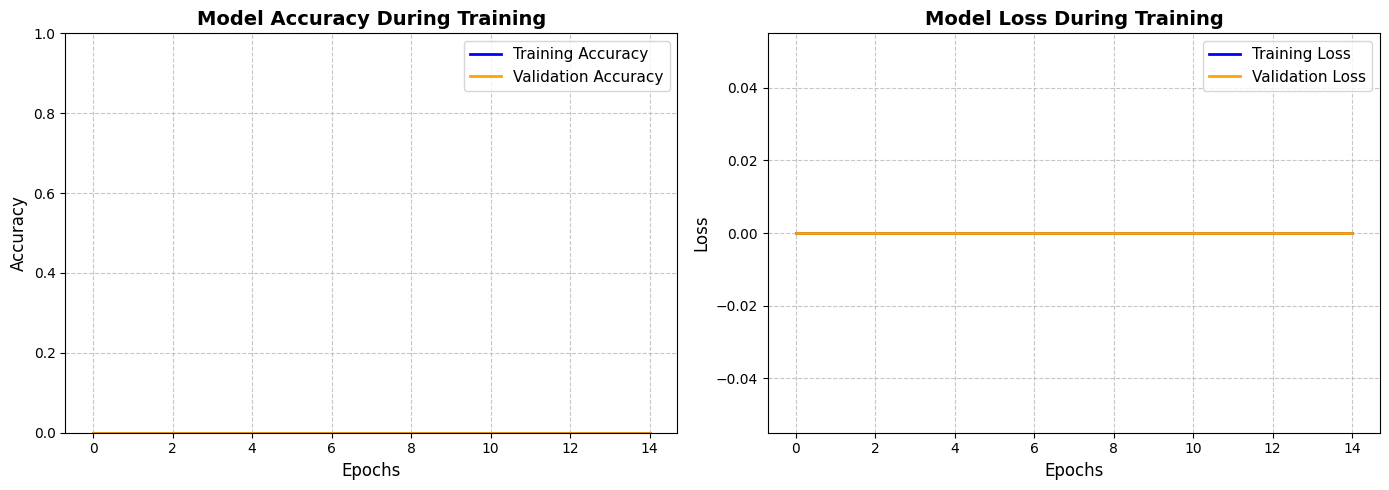

In [12]:
#############################################################################
# GRAPH
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim([0, 1])

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss During Training', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [14]:
#############################################################################
# TEST ACCURACY
test_loss, test_accuracy = model.evaluate(test_set)
print(f"\n Test Accuracy: {test_accuracy * 100:.2f}%")

#############################################################################
# RANDOM AUDIO SAMPLE TEST
for audio_batch, label_batch in test_set.take(1):
    rand_idx = random.randint(0, audio_batch.shape[0] - 1)

    sample = audio_batch[rand_idx:rand_idx+1]
    true_label = label_names[label_batch[rand_idx]]

    prediction = model.predict(sample)
    predicted_label = label_names[np.argmax(prediction)]

    print("\n🎧 Random Audio Test")
    print("True Label:", true_label)
    print("Predicted Label:", predicted_label)

38/38 [==============================] - 1s 23ms/step - loss: 0.0000e+00 - accuracy: 0.0000e+00

 Test Accuracy: 0.00%
1/1 [==============================] - 0s 48ms/step

🎧 Random Audio Test
True Label: free-spoken-digit-dataset-master
Predicted Label: free-spoken-digit-dataset-master
